In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Conv1D, MaxPooling1D,
    Dense, Dropout, BatchNormalization, SpatialDropout1D,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow :", tf.__version__)
print("GPU :", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow : 2.20.0
GPU : False


# **CHARGEMENT DES DONNÉES**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [3]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')
print("Shape :", df.shape)
df.head()


Shape : (500, 12)


,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


# **DISTRIBUTION DES CLASSES**

satisfaction
positive    211
negative    185
neutral     104
Name: count, dtype: int64

satisfaction
positive    42.2 %
negative    37.0 %
neutral     20.8 %
Name: proportion, dtype: object


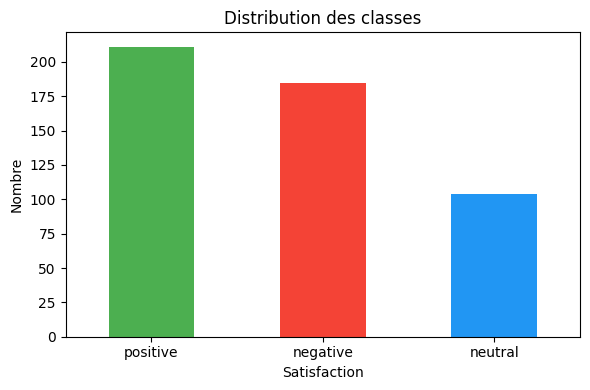

In [4]:
print(df['satisfaction'].value_counts())
print()
print(df['satisfaction'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

plt.figure(figsize=(6, 4))
df['satisfaction'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336', '#2196F3'])
plt.title('Distribution des classes')
plt.xlabel('Satisfaction')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# **PRÉPARATION DU TEXTE**

In [5]:
df['clean_Titre']       = df['clean_Titre'].fillna('')
df['clean_commentaire'] = df['clean_commentaire'].fillna('')

df['full_text'] = (
    df['clean_Titre'].astype(str) + ' ' + df['clean_commentaire'].astype(str)
).str.strip()

lens = df['full_text'].str.split().str.len()
print("Longueur moyenne (mots) :", round(lens.mean(), 1))
print("Longueur max    (mots) :", lens.max())
print("Percentile 95   (mots) :", int(np.percentile(lens, 95)))


Longueur moyenne (mots) : 23.0
Longueur max    (mots) : 204
Percentile 95   (mots) : 60


# **LABEL ENCODING & CLASS WEIGHTS**

In [6]:
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(df['satisfaction'])

print("Classes :", label_encoder.classes_)
print("Mapping :", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_int),
    y=y_int
)
class_weight_dict = dict(enumerate(cw_array))
print("\nClass weights :", {label_encoder.classes_[k]: round(v, 3) for k, v in class_weight_dict.items()})


Classes : ['negative' 'neutral' 'positive']
Mapping : {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Class weights : {'negative': np.float64(0.901), 'neutral': np.float64(1.603), 'positive': np.float64(0.79)}


# **TRAIN / TEST SPLIT & TOKENISATION**

In [7]:
X_text = df['full_text'].values
y_cat  = tf.keras.utils.to_categorical(y_int)

X_train_txt, X_test_txt, y_train, y_test, y_train_int, y_test_int = train_test_split(
    X_text, y_cat, y_int,
    test_size=0.2, random_state=42, stratify=y_int
)

print(f"Train : {len(X_train_txt)} | Test : {len(X_test_txt)}")

# ── Tokenisation (fit sur train uniquement) ───────────────────────────────────
MAX_WORDS = 3000
MAX_LEN   = 60

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_txt)

print(f"Vocabulaire réel : {len(tokenizer.word_index)} mots (limité à {MAX_WORDS})")

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_txt),
                         maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_txt),
                         maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape train : {X_train.shape} | Shape test : {X_test.shape}")


Train : 400 | Test : 100
Vocabulaire réel : 2009 mots (limité à 3000)
Shape train : (400, 60) | Shape test : (100, 60)


# **FONCTIONS UTILITAIRES**

In [8]:
def plot_learning_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    axes[0].set_title(f"Accuracy — {title}", fontsize=13)
    axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',      color='steelblue',  linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    axes[1].set_title(f"Loss — {title}", fontsize=13)
    axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Courbes d'apprentissage — {title}", fontsize=15, fontweight='bold')
    plt.tight_layout(); plt.show()

    best      = np.argmin(history.history['val_loss'])
    gap       = history.history['accuracy'][best] - history.history['val_accuracy'][best]
    print(f"Meilleure époque : {best+1}  |  "
          f"Train={history.history['accuracy'][best]:.4f}  "
          f"Val={history.history['val_accuracy'][best]:.4f} ")


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel('Prédictions'); plt.ylabel('Réel')
    plt.title(f'Matrice de confusion — {title}')
    plt.tight_layout(); plt.show()


def plot_roc(y_true_int, y_pred_probs, title):
    n_classes = len(label_encoder.classes_)
    y_bin     = label_binarize(y_true_int, classes=list(range(n_classes)))
    colors    = ['#F44336', '#FF9800', '#2196F3']
    plt.figure(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(label_encoder.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_probs[:, i])
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')
    auc_mac = roc_auc_score(y_bin, y_pred_probs, average='macro', multi_class='ovr')
    plt.plot([0,1],[0,1],'k--',linewidth=1, label='Aléatoire (0.500)')
    plt.xlabel('FPR', fontsize=12); plt.ylabel('TPR', fontsize=12)
    plt.title(f'Courbes ROC — {title}\nAUC Macro = {auc_mac:.3f}', fontsize=13)
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return auc_mac


def evaluate_model(model, history, title):
    y_probs = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    y_true  = np.argmax(y_test, axis=1)
    print(f"\n{'='*50}\n  {title}\n{'='*50}")
    print(classification_report(y_true, y_pred,
                                 target_names=label_encoder.classes_,
                                 zero_division=0))
    plot_learning_curves(history, title)
    plot_confusion(y_true, y_pred, title)
    auc_mac = plot_roc(y_true, y_probs, title)
    return {
        'Modèle'     : title,
        'Accuracy'   : round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro'   : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'F1 Weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'AUC Macro'  : round(auc_mac, 4),
        '_probs': y_probs, '_pred': y_pred, '_true': y_true,
    }


def make_callbacks(patience_stop=8, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_stop,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=1)
    ]


# **MODÈLE 1 — LSTM SIMPLE**

In [9]:
tf.random.set_seed(42)
np.random.seed(42)

inp = Input(shape=(MAX_LEN,), name='input_lstm')
x   = Embedding(MAX_WORDS, 64, name='embed_lstm')(inp)
x   = SpatialDropout1D(0.2, name='sdrop_lstm')(x)

x   = LSTM(64, return_sequences=True,
           dropout=0.2, recurrent_dropout=0.1,
           name='lstm_layer')(x)

avg = GlobalAveragePooling1D(name='avg_pool_lstm')(x)
mx  = GlobalMaxPooling1D(name='max_pool_lstm')(x)
x   = Concatenate(name='concat_lstm')([avg, mx])

x   = LayerNormalization(name='ln_lstm')(x)
x   = Dropout(0.3, name='drop1_lstm')(x)
x   = Dense(48, activation='relu', name='dense_lstm')(x)
x   = Dropout(0.2, name='drop2_lstm')(x)
out = Dense(3, activation='softmax', name='output_lstm')(x)

model_lstm = Model(inputs=inp, outputs=out, name='LSTM_v3')
model_lstm.build(input_shape=(None, MAX_LEN))

model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model_lstm.summary()


Model: "LSTM_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_lstm          │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_lstm          │ (None, 60, 64)    │    192,000 │ input_lstm[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop_lstm          │ (None, 60, 64)    │          0 │ embed_lstm[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 60, 64)    │     33,024 │ sdrop_lstm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool_lstm       │ (None, 64)        │          0 │ lstm_layer[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_lstm       │ (None, 64)        │          0 │ lstm_layer[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_lstm         │ (None, 128)       │          0 │ avg_pool_lstm[0]… │
│ (Concatenate)       │                   │            │ max_pool_lstm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_lstm             │ (None, 128)       │        256 │ concat_lstm[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1_lstm          │ (None, 128)       │          0 │ ln_lstm[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_lstm (Dense)  │ (None, 48)        │      6,192 │ drop1_lstm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2_lstm          │ (None, 48)        │          0 │ dense_lstm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_lstm (Dense) │ (None, 3)         │        147 │ drop2_lstm[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,619 (904.76 KB)

 Trainable params: 231,619 (904.76 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_stop=10, patience_lr=4),
    verbose=1
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.3187 - loss: 1.1849 - val_accuracy: 0.3125 - val_loss: 1.1213 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4000 - loss: 1.1137 - val_accuracy: 0.3625 - val_loss: 1.0792 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4500 - loss: 1.0640 - val_accuracy: 0.4125 - val_loss: 1.0634 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.4594 - loss: 1.0042 - val_accuracy: 0.5000 - val_loss: 1.0205 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.6156 - loss: 0.9038 - val_accuracy: 0.5125 - val_loss: 0.9524 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7031 - loss: 0.7750 - val_accuracy: 0.6000 - val_loss: 0.8689 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7781 - loss: 0.5830


  LSTM Simple
              precision    recall  f1-score   support

    negative       0.56      0.73      0.64        37
     neutral       0.47      0.33      0.39        21
    positive       0.73      0.64      0.68        42

    accuracy                           0.61       100
   macro avg       0.59      0.57      0.57       100
weighted avg       0.61      0.61      0.60       100



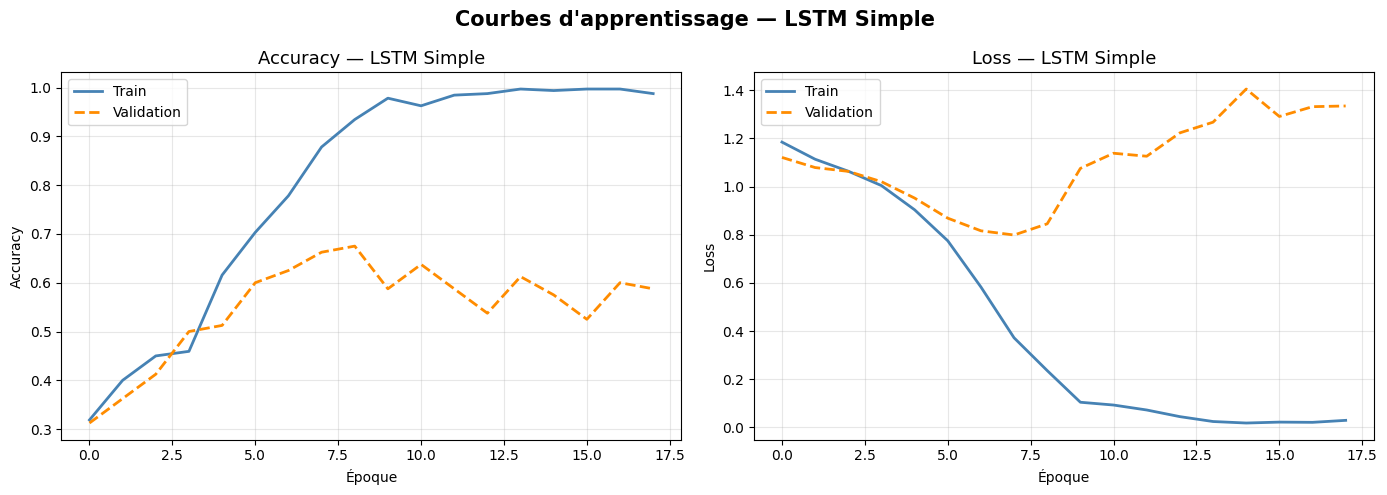

Meilleure époque : 8  |  Train=0.8781  Val=0.6625 


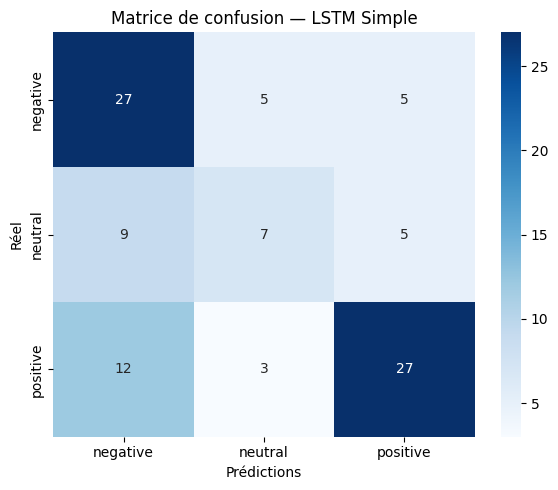

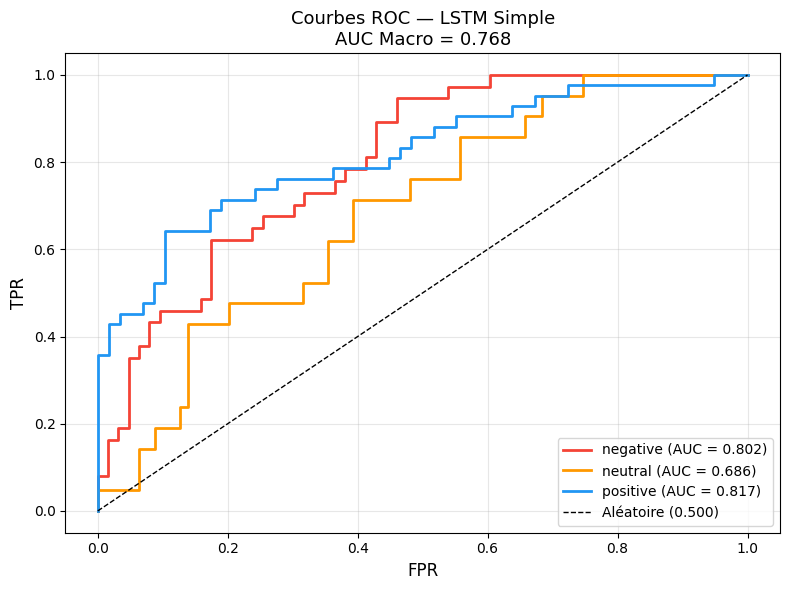

In [11]:
results_lstm = evaluate_model(model_lstm, history_lstm, "LSTM Simple")


# **MODÈLE 2 — CNN + LSTM**


In [12]:
tf.random.set_seed(42)
np.random.seed(42)

inp = Input(shape=(MAX_LEN,), name='input_cnn')
x   = Embedding(MAX_WORDS, 64, name='embed_cnn')(inp)
x   = SpatialDropout1D(0.25, name='sdrop_cnn')(x)

conv2 = Conv1D(64, kernel_size=2, activation='relu', padding='same', name='conv2')(x)
conv3 = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv3')(x)
conv4 = Conv1D(64, kernel_size=4, activation='relu', padding='same', name='conv4')(x)
x     = Concatenate(name='concat_conv')([conv2, conv3, conv4])

x   = LSTM(48, return_sequences=True,
           dropout=0.2, recurrent_dropout=0.1,
           name='lstm_cnn')(x)

avg = GlobalAveragePooling1D(name='avg_pool_cnn')(x)
mx  = GlobalMaxPooling1D(name='max_pool_cnn')(x)
x   = Concatenate(name='concat_pool_cnn')([avg, mx])

x   = LayerNormalization(name='ln_cnn')(x)
x   = Dropout(0.35, name='drop1_cnn')(x)
x   = Dense(48, activation='relu', name='dense_cnn')(x)
x   = Dropout(0.2, name='drop2_cnn')(x)
out = Dense(3, activation='softmax', name='output_cnn')(x)

model_cnn_lstm = Model(inputs=inp, outputs=out, name='CNN_LSTM_v3')
model_cnn_lstm.build(input_shape=(None, MAX_LEN))

model_cnn_lstm.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model_cnn_lstm.summary()


Model: "CNN_LSTM_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_cnn           │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_cnn           │ (None, 60, 64)    │    192,000 │ input_cnn[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop_cnn           │ (None, 60, 64)    │          0 │ embed_cnn[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 60, 64)    │      8,256 │ sdrop_cnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 60, 64)    │     12,352 │ sdrop_cnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv1D)      │ (None, 60, 64)    │     16,448 │ sdrop_cnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_conv         │ (None, 60, 192)   │          0 │ conv2[0][0],      │
│ (Concatenate)       │                   │            │ conv3[0][0],      │
│                     │                   │            │ conv4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_cnn (LSTM)     │ (None, 60, 48)    │     46,272 │ concat_conv[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool_cnn        │ (None, 48)        │          0 │ lstm_cnn[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_cnn        │ (None, 48)        │          0 │ lstm_cnn[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool_cnn     │ (None, 96)        │          0 │ avg_pool_cnn[0][… │
│ (Concatenate)       │                   │            │ max_pool_cnn[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_cnn              │ (None, 96)        │        192 │ concat_pool_cnn[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1_cnn (Dropout) │ (None, 96)        │          0 │ ln_cnn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_cnn (Dense)   │ (None, 48)        │      4,656 │ drop1_cnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2_cnn (Dropout) │ (None, 48)        │          0 │ dense_cnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_cnn (Dense)  │ (None, 3)         │        147 │ drop2_cnn[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 280,323 (1.07 MB)

 Trainable params: 280,323 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_stop=10, patience_lr=4),
    verbose=1
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.2969 - loss: 1.2332 - val_accuracy: 0.4000 - val_loss: 1.1074 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4031 - loss: 1.1233 - val_accuracy: 0.3125 - val_loss: 1.1159 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.3656 - loss: 1.1200 - val_accuracy: 0.2750 - val_loss: 1.0991 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.3688 - loss: 1.1034 - val_accuracy: 0.4375 - val_loss: 1.0729 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.4844 - loss: 1.0263 - val_accuracy: 0.4875 - val_loss: 1.0256 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6062 - loss: 0.8560 - val_accuracy: 0.6500 - val_loss: 0.9133 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7563 - loss: 0.6299 


  CNN + LSTM
              precision    recall  f1-score   support

    negative       0.63      0.70      0.67        37
     neutral       0.29      0.19      0.23        21
    positive       0.67      0.71      0.69        42

    accuracy                           0.60       100
   macro avg       0.53      0.54      0.53       100
weighted avg       0.57      0.60      0.58       100



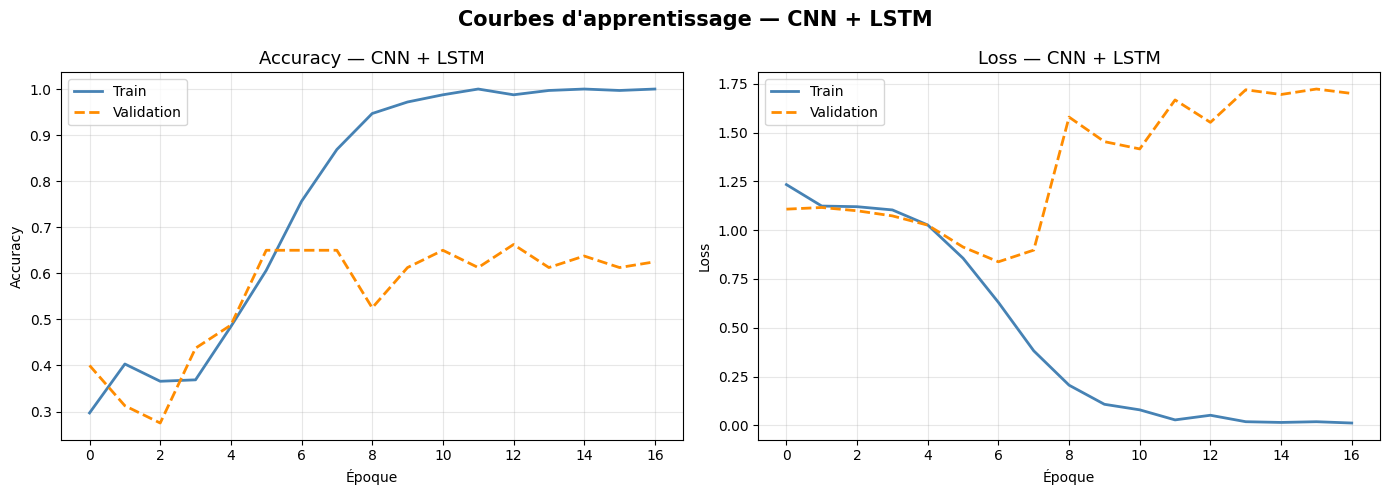

Meilleure époque : 7  |  Train=0.7563  Val=0.6500 


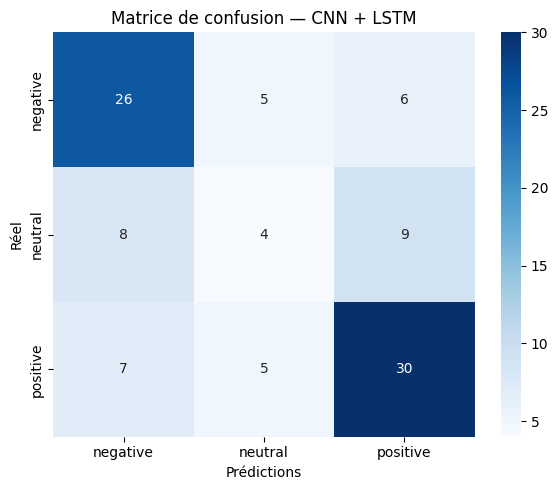

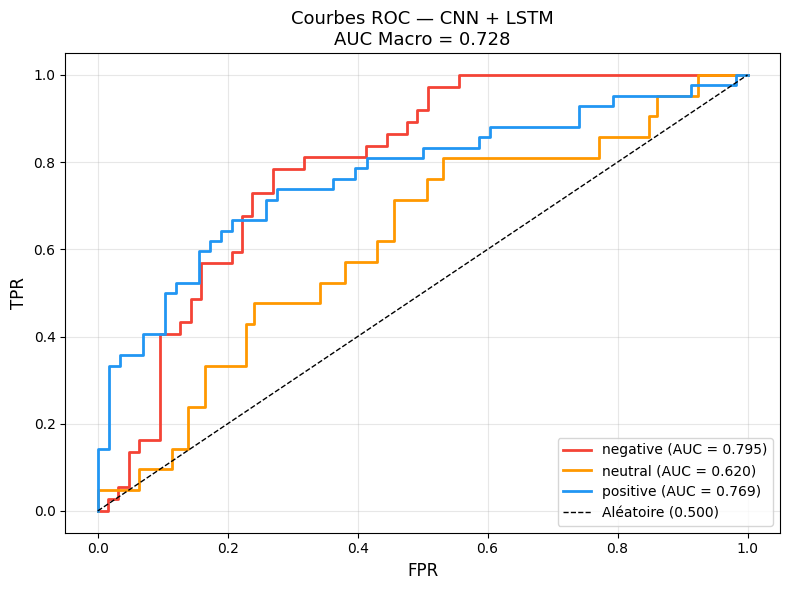

In [14]:
results_cnn_lstm = evaluate_model(model_cnn_lstm, history_cnn_lstm, "CNN + LSTM")


# **MODÈLE 3 — BiLSTM**


In [15]:
tf.random.set_seed(42)
np.random.seed(42)

inp = Input(shape=(MAX_LEN,), name='input_bilstm')
x   = Embedding(MAX_WORDS, 64, name='embed_bilstm')(inp)
x   = SpatialDropout1D(0.25, name='sdrop_bilstm')(x)

x   = Bidirectional(LSTM(
        48, return_sequences=True,
        dropout=0.2, recurrent_dropout=0.1,
        name='bilstm_layer'
      ), name='bilstm')(x)

avg = GlobalAveragePooling1D(name='avg_pool_bilstm')(x)
mx  = GlobalMaxPooling1D(name='max_pool_bilstm')(x)
x   = Concatenate(name='concat_bilstm')([avg, mx])

x   = LayerNormalization(name='ln_bilstm')(x)
x   = Dropout(0.4, name='drop1_bilstm')(x)
x   = Dense(48, activation='relu',
            kernel_regularizer=l2(5e-4),
            name='dense_bilstm')(x)
x   = Dropout(0.25, name='drop2_bilstm')(x)
out = Dense(3, activation='softmax', name='output_bilstm')(x)

model_bilstm = Model(inputs=inp, outputs=out, name='BiLSTM_v3')
model_bilstm.build(input_shape=(None, MAX_LEN))

model_bilstm.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)
model_bilstm.summary()


Model: "BiLSTM_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_bilstm        │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_bilstm        │ (None, 60, 64)    │    192,000 │ input_bilstm[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sdrop_bilstm        │ (None, 60, 64)    │          0 │ embed_bilstm[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 60, 96)    │     43,392 │ sdrop_bilstm[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool_bilstm     │ (None, 96)        │          0 │ bilstm[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_bilstm     │ (None, 96)        │          0 │ bilstm[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bilstm       │ (None, 192)       │          0 │ avg_pool_bilstm[… │
│ (Concatenate)       │                   │            │ max_pool_bilstm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_bilstm           │ (None, 192)       │        384 │ concat_bilstm[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1_bilstm        │ (None, 192)       │          0 │ ln_bilstm[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_bilstm        │ (None, 48)        │      9,264 │ drop1_bilstm[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2_bilstm        │ (None, 48)        │          0 │ dense_bilstm[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_bilstm       │ (None, 3)         │        147 │ drop2_bilstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 245,187 (957.76 KB)

 Trainable params: 245,187 (957.76 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(patience_stop=10, patience_lr=4),
    verbose=1
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.3562 - loss: 1.2286 - val_accuracy: 0.3125 - val_loss: 1.1594 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.3938 - loss: 1.1547 - val_accuracy: 0.3875 - val_loss: 1.1464 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.4031 - loss: 1.1293 - val_accuracy: 0.4125 - val_loss: 1.1190 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.4812 - loss: 1.0829 - val_accuracy: 0.4375 - val_loss: 1.0965 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.5500 - loss: 1.0431 - val_accuracy: 0.5875 - val_loss: 1.0237 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5906 - loss: 0.9614 - val_accuracy: 0.6000 - val_loss: 0.9604 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.7500 - loss: 0


  BiLSTM
              precision    recall  f1-score   support

    negative       0.58      0.76      0.66        37
     neutral       0.31      0.24      0.27        21
    positive       0.72      0.62      0.67        42

    accuracy                           0.59       100
   macro avg       0.54      0.54      0.53       100
weighted avg       0.58      0.59      0.58       100



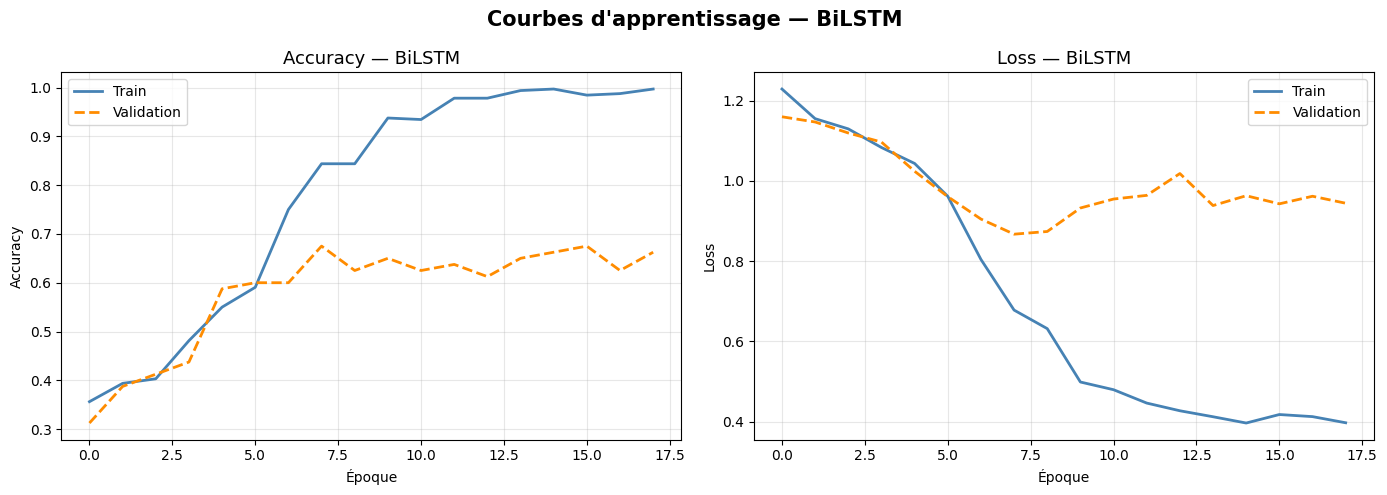

Meilleure époque : 8  |  Train=0.8438  Val=0.6750 


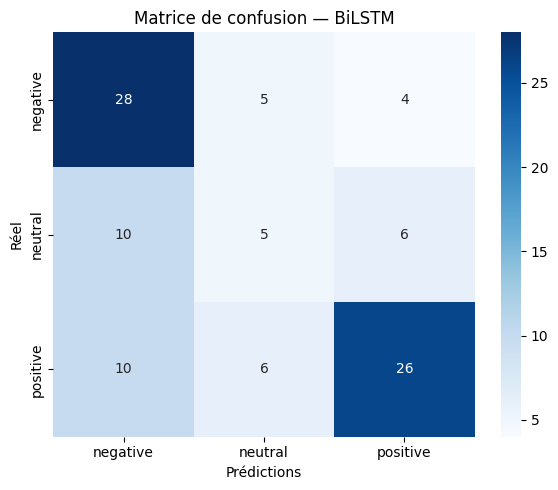

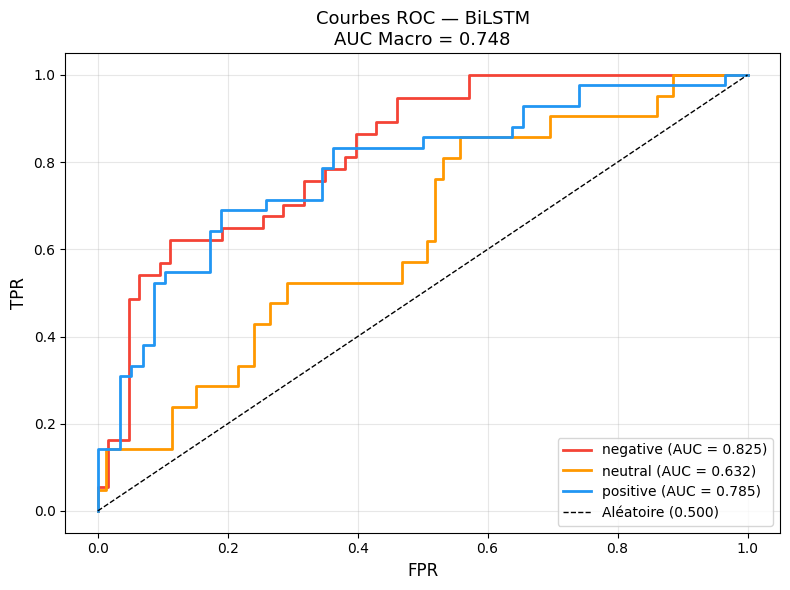

In [17]:
results_bilstm = evaluate_model(model_bilstm, history_bilstm, "BiLSTM")


# **COMPARAISON FINALE DES 3 MODÈLES**

In [18]:
metrics_keys = ['Modèle', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'AUC Macro']
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k in metrics_keys}
    for r in [results_lstm, results_cnn_lstm, results_bilstm]
])
print(df_results.to_string(index=False))


     Modèle  Accuracy  F1 Macro  F1 Weighted  AUC Macro
LSTM Simple      0.61    0.5692       0.6038     0.7681
 CNN + LSTM      0.60    0.5283       0.5843     0.7277
     BiLSTM      0.59    0.5319       0.5805     0.7475


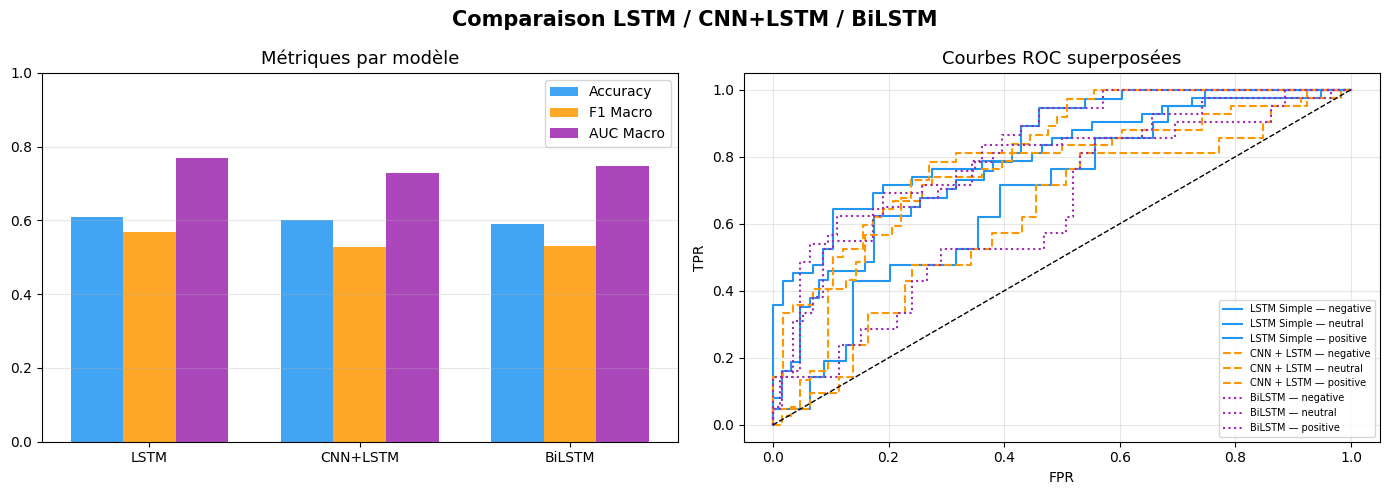

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models   = ['LSTM', 'CNN+LSTM', 'BiLSTM']
acc_vals = [results_lstm['Accuracy'],  results_cnn_lstm['Accuracy'],  results_bilstm['Accuracy']]
f1_vals  = [results_lstm['F1 Macro'],  results_cnn_lstm['F1 Macro'],  results_bilstm['F1 Macro']]
auc_vals = [results_lstm['AUC Macro'], results_cnn_lstm['AUC Macro'], results_bilstm['AUC Macro']]

x = np.arange(len(models))
w = 0.25
axes[0].bar(x - w, acc_vals, w, label='Accuracy',  color='#2196F3', alpha=0.85)
axes[0].bar(x,     f1_vals,  w, label='F1 Macro',  color='#FF9800', alpha=0.85)
axes[0].bar(x + w, auc_vals, w, label='AUC Macro', color='#9C27B0', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1); axes[0].set_title('Métriques par modèle', fontsize=13)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# ROC superposées
n_classes   = len(label_encoder.classes_)
line_styles = ['-', '--', ':']
colors      = ['#2196F3', '#FF9800', '#9C27B0']
for res, ls, color in zip([results_lstm, results_cnn_lstm, results_bilstm],
                           line_styles, colors):
    y_bin = label_binarize(res['_true'], classes=list(range(n_classes)))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], res['_probs'][:, i])
        axes[1].plot(fpr, tpr, linestyle=ls, color=color, linewidth=1.5,
                     label=f"{res['Modèle']} — {label_encoder.classes_[i]}")
axes[1].plot([0,1],[0,1],'k--',linewidth=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Courbes ROC superposées', fontsize=13)
axes[1].legend(fontsize=7, loc='lower right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparaison LSTM / CNN+LSTM / BiLSTM', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
